In [106]:
# %%
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from PIL import Image

# Define the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [107]:
# %%
data_dir = r"D:\AI Mini project (AI vs Real image)\archive"

from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((128, 128)),       # Resize all images to 128x128
    transforms.ToTensor(),               # Convert to PyTorch tensor (C×H×W)
    transforms.Normalize((0.5, 0.5, 0.5),  # Mean for each channel (R, G, B)
                         (0.5, 0.5, 0.5))  # Std deviation for each channel
])


# Load the dataset (no need for the whole split/loader part, just the object for class names)
# NOTE: If your 'archive' folder is large, this might take a moment, but it's required for class_names
try:
    train_data = datasets.ImageFolder(root=os.path.join(data_dir, "train"), transform=transform)
except Exception:
    # Fallback if the path is complex or you only need the assumed class names
    class_names = ['AI', 'Real'] # Assuming alphabetical order from your dataset folders
    print("Warning: Could not fully load train_data, assuming class names are ['AI', 'Real']")

In [108]:
# %%
model = models.resnet18(pretrained=True)
for param in model.parameters():
    param.requires_grad = False  # freeze base layers

num_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Linear(num_features, 256),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(256, 2),  # real vs fake
    nn.Softmax(dim=1)
)
model = model.to(device)

⚙️ Using device: cpu
✅ Model weights loaded successfully from: resnet18_cifake_classifier.pth
------------------------------------------------------------
🖼️ Image Path: D:\AI Mini project (AI vs Real image)\test1.jpg
🔮 Predicted Class: AI
📊 Confidence: 100.00%
------------------------------------------------------------


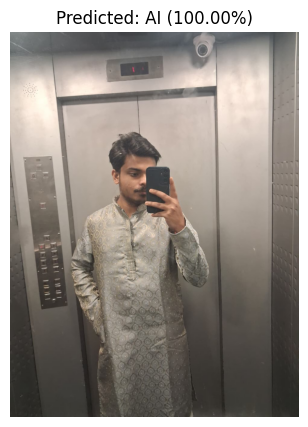

In [109]:
# %%
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import matplotlib.pyplot as plt

# ====================================================
# 1️⃣ Device setup
# ====================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"⚙️ Using device: {device}")

# ====================================================
# 2️⃣ Model architecture (MUST MATCH TRAINING EXACTLY)
# ====================================================
model = models.resnet18(pretrained=True)
for param in model.parameters():
    param.requires_grad = False  # freeze feature extractor

num_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Linear(num_features, 256),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(256, 2),  # real vs fake
    nn.Softmax(dim=1)
)
model = model.to(device)

# ====================================================
# 3️⃣ Load trained weights
# ====================================================
model_save_path = "resnet18_cifake_classifier.pth"

try:
    model.load_state_dict(torch.load(model_save_path, map_location=device))
    model.eval()
    print(f"✅ Model weights loaded successfully from: {model_save_path}")
except Exception as e:
    print(f"❌ Error loading model weights: {e}")
    raise

# ====================================================
# 4️⃣ Image preprocessing (same as training)
# ====================================================
image_path = r"D:\AI Mini project (AI vs Real image)\test1.jpg"

inference_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# ====================================================
# 5️⃣ Load and prepare the image
# ====================================================
try:
    img = Image.open(image_path).convert("RGB")
    img_tensor = inference_transform(img).unsqueeze(0).to(device)
except Exception as e:
    print(f"❌ Error loading image: {e}")
    raise

# ====================================================
# 6️⃣ Make prediction
# ====================================================
with torch.no_grad():
    output = model(img_tensor)
    prediction_index = torch.argmax(output, dim=1).item()
    prediction_probability = output[0, prediction_index].item() * 100

# ====================================================
# 7️⃣ Class names (based on your dataset)
# ====================================================
class_names = ['AI', 'Real']  # Adjust if reversed during training
predicted_class = class_names[prediction_index]

# ====================================================
# 8️⃣ Show results
# ====================================================
print("-" * 60)
print(f"🖼️ Image Path: {image_path}")
print(f"🔮 Predicted Class: {predicted_class}")
print(f"📊 Confidence: {prediction_probability:.2f}%")
print("-" * 60)

plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.title(f"Predicted: {predicted_class} ({prediction_probability:.2f}%)")
plt.axis("off")
plt.show()


✅ Model loaded successfully!
🖼️ Real image prediction:


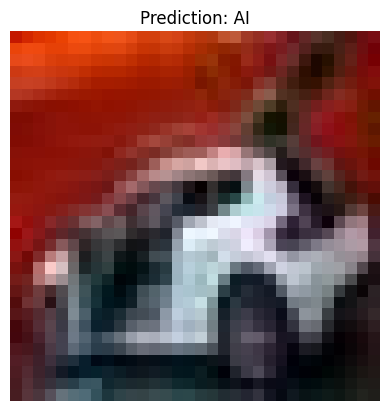


🤖 AI image prediction:


FileNotFoundError: [Errno 2] No such file or directory: 'D:\\AI Mini project (AI vs Real image)\\test\\FAKE\\0 (2).jpg'

In [115]:
# %% --- Imports ---
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

# %% --- Device setup ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# %% --- Define same transforms used during training ---
transform = transforms.Compose([
    transforms.Resize((128, 128)),        # same as training
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# %% --- Recreate the same model architecture ---
model = models.resnet18(pretrained=False)
num_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Linear(num_features, 256),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(256, 2)   # 2 classes: Real, AI
)
model = model.to(device)

# %% --- Load trained weights ---
model.load_state_dict(torch.load("resnet18_cifake_classifier.pth", map_location=device))
model.eval()

print("✅ Model loaded successfully!")

# %% --- Helper: predict function ---
def predict_image(img_path):
    # Load image
    image = Image.open(img_path).convert("RGB")
    img_tensor = transform(image).unsqueeze(0).to(device)

    # Forward pass
    with torch.no_grad():
        output = model(img_tensor)
        pred = torch.argmax(output, 1).item()

    # Label mapping
    labels = ["REAL", "AI"]
    predicted_label = labels[pred]

    # Display image and prediction
    plt.imshow(np.array(image))
    plt.title(f"Prediction: {predicted_label}")
    plt.axis("off")
    plt.show()

    return predicted_label

# %% --- Test with one real and one fake image ---
real_image_path = r"D:\AI Mini project (AI vs Real image)\archive\test\REAL\0000 (2).jpg"
fake_image_path = r"D:\AI Mini project (AI vs Real image)\test\FAKE\0 (2).jpg"

print("🖼️ Real image prediction:")
predict_image(real_image_path)

print("\n🤖 AI image prediction:")
predict_image(fake_image_path)


In [ ]:
import torch.nn.functional as F

def generate_gradcam(model, input_tensor, target_layer, class_idx=None):
    model.eval()
    features, gradients = [], []

    def forward_hook(module, inp, out):
        features.append(out)
        out.retain_grad()

    def backward_hook(module, grad_in, grad_out):
        gradients.append(grad_out[0])

    h1 = target_layer.register_forward_hook(forward_hook)
    h2 = target_layer.register_backward_hook(backward_hook)

    # Temporarily remove softmax
    if isinstance(model.fc, nn.Sequential):
        layers = list(model.fc.children())
        if isinstance(layers[-1], nn.Softmax):
            layers = layers[:-1]
            model.fc = nn.Sequential(*layers)

    # Forward pass (raw logits)
    output = model(input_tensor)
    pred_class = output.argmax(dim=1).item()

    # Choose which class to visualize
    if class_idx is None:
        class_idx = pred_class

    score = output[0, class_idx]
    model.zero_grad()
    score.backward()

    grads = gradients[0]
    acts = features[0]
    weights = grads.mean(dim=(2, 3), keepdim=True)
    cam = (weights * acts).sum(dim=1, keepdim=True)
    cam = torch.relu(cam)
    cam = cam.squeeze().detach().cpu().numpy()
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
    cam = np.uint8(255 * cam)

    h1.remove()
    h2.remove()
    return cam, pred_class


# --- Run Grad-CAM ---
target_layer = model.layer4[-1].conv2
heatmap, pred_class = generate_gradcam(model, img_t, target_layer, class_idx=1)  # 

# --- Show result ---
img_np = np.array(img.resize((224, 224))) / 255.0
plt.figure(figsize=(5,5))
plt.imshow(img_np)
plt.imshow(heatmap, cmap="jet", alpha=0.5)
plt.title(f"Grad-CAM | Class Explained: {'Fake' if 1 else 'Real'} | Model Predicted: {['Real','Fake'][pred_class]}")
plt.axis("off")
plt.show()


RuntimeError: can't retain_grad on Tensor that has requires_grad=False

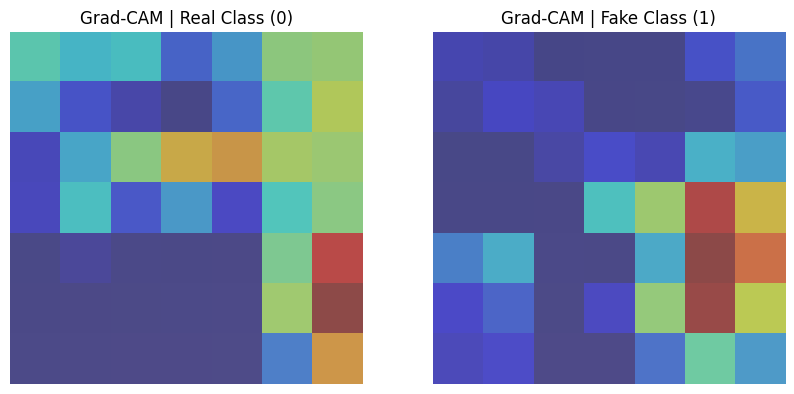

✅ Model Predicted: Fake


In [ ]:
# Generate both heatmaps
real_heatmap, _ = generate_gradcam(model, img_t, target_layer, class_idx=0)
fake_heatmap, pred_class = generate_gradcam(model, img_t, target_layer, class_idx=1)

# Plot side by side
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
img_np = np.array(img.resize((224, 224))) / 255.0

axs[0].imshow(img_np)
axs[0].imshow(real_heatmap, cmap="jet", alpha=0.5)
axs[0].set_title("Grad-CAM | Real Class (0)")
axs[0].axis("off")

axs[1].imshow(img_np)
axs[1].imshow(fake_heatmap, cmap="jet", alpha=0.5)
axs[1].set_title("Grad-CAM | Fake Class (1)")
axs[1].axis("off")

plt.show()

print(f"✅ Model Predicted: {['Real','Fake'][pred_class]}")
